## Learning Objectives

After this lesson, you will be able to:
- Understand the concepts of raster-vector integration in spatial data analysis.
- Perform zonal statistics to summarize raster data by vector boundaries.
- Combine geospatial and tabular data to analyze population-weighted exposure.
- Visualize and interpret spatial patterns in air pollution exposure.

## Spatial Aggregation Analysis Using Raster and Vector Data

Datasets
- PM2.5 Raster: 1 km resolution GeoTIFF over the U.S.
- County Shapefile: U.S. counties with demographic fields.

Objective
- Calculate the population-weighted PM2.5 concentration.

Population-weighted PM2.5 is a statistical measure that represents the average PM2.5 concentration experienced by people, rather than just the spatial average over land or administrative units. It is calculated by weighting the PM2.5 concentration in each geographic unit (e.g., county or grid cell) by the population living in that unit:
$$
\text{Population-weighted PM}_{2.5} = \frac{\sum_i (\text{PM}_{2.5,i} \times \text{Population}_i)}{\sum_i \text{Population}_i}
$$

A population-weighted average gives more weight to populated regions, making it a better measure of actual human exposure to air pollution. If rural areas have low PM2.5 but low population, and cities have high PM2.5 with high population, the population-weighted PM2.5 will be closer to the urban levels, reflecting what most people actually breathe.

In [1]:
# Load Libraries
import geopandas as gpd
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rxr
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore")

# Load PM2.5 Raster
pm25_filepath = 'data/USHAP_PM2.5_D1K_20180815_V1.tif'
pm25 = rxr.open_rasterio(pm25_filepath,masked=True).squeeze()
print(pm25.rio.crs)

# Load the Shapefile
counties = gpd.read_file("data/USCounties.zip")
print(counties.crs)

EPSG:4326
EPSG:5070


We can see the two datasets have different crs. Let's first reproject the raster data to match the counties crs.

In [2]:
# Reproject Raster to Match Vector CRS
pm25 = pm25.rio.reproject(counties.crs)
print(pm25.rio.crs)

EPSG:5070


Let's plot the pm2.5 to take a look at the air quality condition:

Text(0.5, 1.0, 'PM2.5 Concentration on August 15 2018')

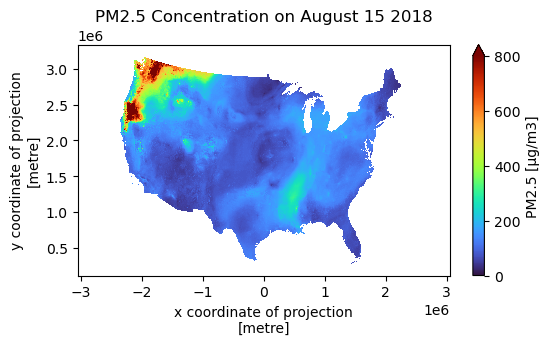

In [3]:
fig, ax = plt.subplots(1,1,figsize=(6,3))
pm25.plot(ax=ax,vmin=0,vmax=800,cmap='turbo')
ax.set_title('PM2.5 Concentration on August 15 2018')

The map shows bad air quality in the Pacific Northwest. In mid-August 2018, wildfires across the western United States and Canada burned thousands of acres and destroyed numerous structures. Wildfires release greenhouse gases and produce black carbon pollution. This sooty black material comes from the incomplete combustion of fossil fuels and vegetation, and it is easily transported by winds. Black carbon can cause respiratory and cardiovascular problems if inhaled, and it can also affect climate. The map above shows plumes of black carbon associated with the western wildfires on August 15 2018.

Next step is to use zonal_stats to perform spatial aggregation of PM2.5 over the U.S. counties. To increase computational speed, we will focus on the most impacted states:

In [4]:
# Calculate mean PM2.5 in each county
# Select counties within specific Western U.S. states
# This step filters the full counties GeoDataFrame to only include those in the listed states
county_impacted = counties[counties.STATE_NAME.isin(['Washington','Oregon','California','Nevada','Idaho','Montana',])]

# Get the affine transformation matrix from the PM2.5 raster
# The affine transform is required to relate array indices to geographic coordinates
affine = pm25.rio.transform()

# Perform zonal statistics: calculate the mean PM2.5 value for each county polygon
# - county_impacted: GeoDataFrame with selected counties
# - pm25.values: 2D numpy array from the raster
# - affine: provides geolocation mapping from pixel grid to real-world coordinates
# - stats=["mean"]: specify the statistics to compute (mean in this case)
# - geojson_out=True: return results as GeoJSON features, allowing easy conversion to GeoDataFrame

zs = zonal_stats(
    county_impacted,
    pm25.values,
    affine=affine,
    stats=["mean"],
    all_touched=True, # includes all raster cells touched by the polygon boundary.
    geojson_out=True,
    )

# Convert the list of GeoJSON features to a GeoDataFrame
# Each feature includes both geometry and the computed statistics
pm25_gdf = gpd.GeoDataFrame.from_features(zs)

# Rename the column "mean" to "pm25_mean" for clarity and consistency
pm25_gdf.rename(columns={"mean": "pm25_mean"}, inplace=True)

pm25_gdf.head(5)

,geometry,ObjectID,NAME,STATE_NAME,FIPS,POP2000,POP00_SQMI,MALES,FEMALES,MED_AGE,...,CountyAcre,CalcFarmAc,FarmAcres,CropAcres,CrpValAv,CrpValTot,FrmrAge,Cows,AvgAge,pm25_mean
0,"POLYGON ((-2263443.001 2373524.342, -2263269.8...",0,Siskiyou,California,06093,44301,7.0,21752,22549,43.0,...,164399000.0,628914.0,628914.0,182185.0,719.83,1.311422e+08,56.4,66665,63.743756,881.817744
1,"POLYGON ((-961891.533 2507738.015, -961894.810...",1,Big Horn,Montana,30003,12671,2.5,6249,6422,29.8,...,129878000.0,2770310.0,2770310.0,407958.0,104.68,4.270504e+07,54.2,86434,20.910138,156.720160
2,"POLYGON ((-2292563.856 2394672.986, -2292561.7...",8,Del Norte,California,06015,27507,27.1,15186,12321,36.4,...,26251100.0,13332.0,13332.0,8039.0,3414.01,2.744523e+07,55.8,9858,42.229026,506.050472
3,"POLYGON ((-2028816.907 2640191.920, -2029870.1...",9,Linn,Oregon,41043,103069,44.6,50880,52189,37.4,...,59830700.0,393764.0,393764.0,304964.0,481.70,1.469012e+08,55.3,32958,46.734171,462.407243
4,"POLYGON ((-2179108.518 2686663.840, -2179075.9...",10,Benton,Oregon,41003,78153,115.1,38905,39248,31.1,...,17585600.0,130680.0,130680.0,91750.0,940.55,8.629546e+07,54.1,6887,29.733635,259.293790


We can see `pm25_gdf` includes data from the U.S. counties dataset and a new column for PM2.5, which allows us to perform population exposure analysis. Now let's plot the pm2.5 averaged for each county:

Text(0.5, 1.0, 'County-average PM2.5 Concentration')

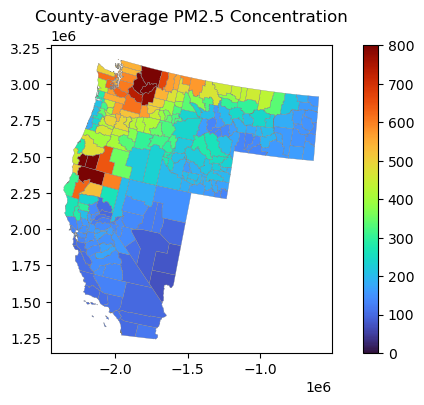

In [5]:
fig, ax = plt.subplots(1,1,figsize=(8,4))
pm25_gdf.plot(ax=ax,column='pm25_mean',vmin=0,vmax=800,cmap='turbo',legend=True)
pm25_gdf.plot(ax=ax,fc='none',ec='gray',lw=.2)
ax.set_title('County-average PM2.5 Concentration')

In [6]:
# Calculate population-weighted PM2.5 exposure
# This metric accounts for both air quality (PM2.5 concentration) and population distribution,
# giving a better estimate of the overall exposure burden.

# Multiply mean PM2.5 value by population for each county
# This creates a new column representing the total "exposure load" for each county
pm25_gdf["pop_pm25"] = pm25_gdf["pm25_mean"] * pm25_gdf["POP2000"]

# Calculate the total population across all counties
# This will serve as the denominator for population-weighted averaging
total_pop = pm25_gdf["POP2000"].sum()

# Compute the population-weighted average PM2.5
# This divides the total exposure load by the total population
# It answers: "What is the average PM2.5 exposure experienced by a typical person?"
pop_weighted_pm25 = pm25_gdf["pop_pm25"].sum() / total_pop

print(f"Population-weighted PM2.5 for the entire domain: {pop_weighted_pm25:.2f} µg/m³")

Population-weighted PM2.5 for the entire domain: 208.04 µg/m³


The above cell computes the population-weighted PM2.5 for the entire region. What if we want to compute the population-weighted PM2.5 for each state?

In [7]:
# Group by state and calculate total exposure and total population
state_agg = pm25_gdf.groupby("STATE_NAME").agg({
    "pop_pm25": "sum",    # total exposure load
    "POP2000": "sum"      # total population
}).reset_index()

# Compute population-weighted PM2.5 for each state
state_agg["pw_pm25"] = state_agg["pop_pm25"] / state_agg["POP2000"]
print(state_agg)

   STATE_NAME      pop_pm25   POP2000     pw_pm25
0  California  4.158987e+09  33871648  122.786663
1       Idaho  3.376491e+08   1293953  260.943902
2     Montana  2.177889e+08    902195  241.398938
3      Nevada  2.011585e+08   1998257  100.666983
4      Oregon  1.548807e+09   3421399  452.682283
5  Washington  3.393103e+09   5894121  575.675798
